# Does a long upper wick after a slide really mark a floor? 🔻
### The inverted hammer — the candle traders swear catches the bounce, on the real tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Deeper_washout_rescues_it%3F: Busted](https://img.shields.io/badge/Deeper_washout_rescues_it%3F-Busted-8b949e?style=flat-square)

Here's a chart pattern taught in every trading course. After a stock has been sliding, a day prints with a **tiny body near the bottom** of its range and a **long tail pointing up** — buyers pushed price up during the session, even if sellers clawed most of it back by the close. Traders call it an **inverted hammer**: *"buyers showed up — the sellers are running out of ammo, buy the bounce."*

The wick **is** real information about *that day* — buyers genuinely tested higher. The question is whether it tells you anything about the **next few days**. We checked, on **60+ years** of daily bars across 26 big US stocks plus the S&P.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Fixed **26-name** survivor basket + SPY (names still trading today) — the same panel used by the sibling hammer/shooting-star studies. Survivors *recover* from dips that delisted names didn't, so the bias actually leans **toward** finding a bounce. If even *that* shows no floor, the floor really isn't there. Charts are drawn by the code beside them; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inverted_hammer import data, strategy as st

HS = [1, 3, 5, 10]
ASOF = "2026-06-30"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = {t: b[b.index <= ASOF] for t, b in data.load_real().items()}
else:
    PANEL = None
print("real inverted-hammer cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '1962-01-02', 'end': '2026-06-30', 'n_names': 26, 'n_bars': 345846, 'n_shape': 10735, 'fp_panel': '8ddaab4e2e1e', 'fp_spy': '7987ab25910e', 'invh': {1: (4895, 0.045, 49.4, 1.45, 0.042, 0.166, -0.055), 3: (4895, 0.095, 52.2, 1.79, 0.021, 0.082, -0.005), 5: (4894, 0.105, 52.6, 1.49, 0.035, 0.142, 0.005), 10: (4891, 0.137, 55.7, 1.48, 0.046, 0.185, 0.037)}, 'star': {1: (5673, 3.3, 49.6, 1.48, 0.093), 3: (5673, 4.5, 51.6, 1.12, 0.151), 5: (5673, 6.5, 53.0, 1.21, 0.115), 10: (5669, -0.5, 53.3, -0.07, 0.53)}, 'anyside': {1: (10735, 3.9, 49.5, 2.13, 0.014), 3: (10735, 6.9, 51.8, 2.23, 0.013), 5: (10734, 8.3, 52.8, 1.97, 0.016), 10: (10727, 5.6, 54.3, 0.91, 0.149)}, 'filt': [('plain (lookback 10)', 0.095, 1.79, 0.021, 4895), ('trend lookback 5', 0.134, 2.64, 0.002, 4906), ('trend lookback 20', 0.077, 1.41, 0.045, 4785), ('min washout >= 5%', 0.413, 2.85, 0.0, 1265), ('min washout >= 10%', 0.527, 1.02, 0.015, 257), ('wick >= 3x body', 0.072, 0.94, 0.137, 2486), ('wick >= 4x body', 0.092, 0.87, 0.136, 1408)], 'costs': [(0.0, 9.5), (1.0, 7.5), (5.0, -0.5), (10.0, -10.5)], 'n_names_over2': 2, 'syn': [(0.0, 2508, 0.014, 0.57, 0.267, 52.0), (0.005, 2492, 0.321, 12.78, 0.0, 61.4)]}


real inverted-hammer cache present: True | names: 26


## The answer first

| Question | Answer |
|---|---|
| After a slide, does an inverted hammer mark a floor? | **Not really.** Over the next 3 days it beats the stock's own usual return by **+0.095%** — a real-looking tilt (*t* = +1.79) but it never crosses the bar the desk requires (*t* ≥ 2), and testing four different holding periods at once means we have to correct for multiple guesses — once we do, none of them survive. |
| Does the direction (after a *slide* vs after a *rally*) even matter? | **Barely.** The identical wick shape after an *uptrend* — the bearish look-alike — shows almost the same small positive tilt. If the story were really about sellers exhausting after a decline, the "wrong side" should look different. It doesn't. |
| Can I fix it with a filter? | **That's the tell.** A shorter trend window or a deeper "real washout" filter can nudge the number up — but push the washout filter *further* and it **falls back down**, and demanding a *bigger, purer* wick (the "better" inverted hammer) makes it **worse**. |
| Could I trade it? | **No.** After normal trading costs the edge turns negative at every horizon that mattered — the best horizon's net edge is a rounding error either side of zero. |

> The wick is real — for *that day*. As a forecast of the *next* few days, the floor is a **mirage**. And we *prove* our test isn't blind: when we secretly plant a real floor in fake data, the same test screams (more in the quant notebook).

## 1 · The claim

> *"An inverted hammer is a small body near the bottom of the range with a long upper shadow. After a downtrend it's **bullish** — buyers tested higher and sellers are losing steam, so the bottom is near. The same candle after an uptrend is the bearish **shooting star**."*

This isn't fringe. It's core to **Steve Nison**'s *Japanese Candlestick Charting Techniques* (1991) — the book that brought 18th-century Japanese rice-trading candles to Wall Street — and it's in every charting app and trading course made since. So the question isn't "is it a known pattern?" It's: **does the long upper wick actually predict what happens next?**

## 2 · So what?

If a single candle could call the bottom, you'd have a beautifully simple edge — look at one bar, take the trade. That's exactly why the pattern is so beloved and so widely taught.

But two traps hide here. **(1)** A long upper wick says price *did* get bid up today — that's backward-looking and already in the close. Whether it forecasts *tomorrow* is a separate, much harder claim. **(2)** Big liquid stocks **drift up** over time, so *any* random day after a slide often looks "bullish" a few days later — that's mean-reversion and drift, not the candle. The honest test isn't "does the stock rise after an inverted hammer?" (it usually does — everything does) — it's **"does it rise more than the stock's own normal?"** We measure that base-rate-adjusted edge, and we correct for the fact that we're testing four different holding periods at once.

## 3 · How would we even know?

We scan **345,846 daily bars** across **26 stocks + SPY** (1962-01-02 → 2026-06-30) and flag every bar with the inverted-hammer shape — small body at the bottom, upper wick at least twice the body, almost no lower shadow. That's **10,735** inverted-hammer-shaped bars in total, of which **4,895** sit after a genuine downtrend (the bullish claim).

1. **The shape.** Detected by exact open/high/low/close rules — no eyeballing.
2. **The trend split.** Was the stock *down* over the last 10 days? Only those count as the bullish claim; the same shape after an *up* move is the bearish look-alike (sibling study).
3. **The forward move.** Starting at the **next** day's close (no cheating — the candle is already done), how does the stock do over the next **1, 3, 5, 10** days **versus its own usual return** over that horizon?
4. **The honesty check.** Testing four horizons at once means one of them can look good by chance — we apply a **Bonferroni** correction so a lucky horizon can't carry the headline.

If the legend is real, the inverted hammer should beat the base rate by a clear, robust margin. We'd call it a **mirage** if the edge can't clear a basic luck test.

## 4 · The teardown — let's actually look

**The bullish claim first.** Here's how much the inverted hammer beats (or misses) the stock's *own normal* return at each horizon. If the floor is real, these bars should be clearly, solidly green — and the *t*-stats (the honesty line) should clear 2.

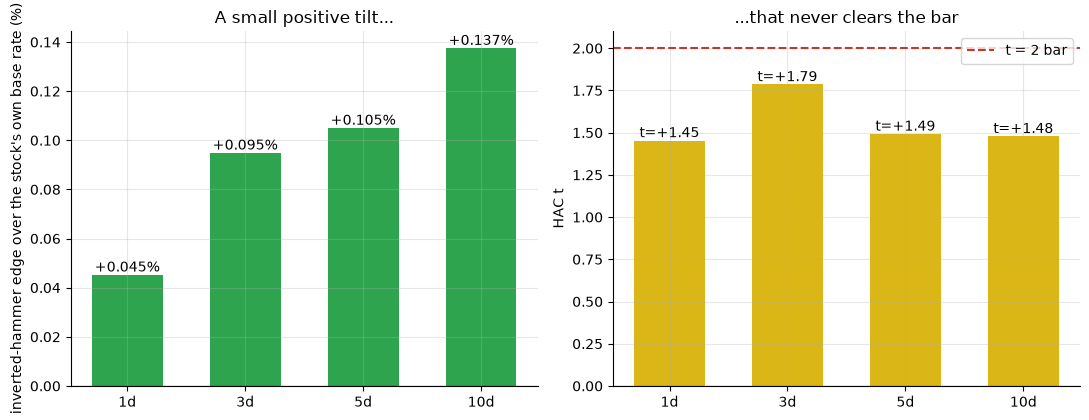

edge by horizon (%): [0.045, 0.095, 0.105, 0.137]  t: [1.45, 1.79, 1.49, 1.48]


In [2]:
if HAVE_REAL:
    res = st.run_experiment(PANEL, side='invhammer', n_draws=1500, seed=684)
    edge = [res[h]['edge_mean']*100 for h in HS]; tvals = [res[h]['t'] for h in HS]
else:
    edge = [R['invh'][h][1] for h in HS]; tvals = [R['invh'][h][3] for h in HS]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
cols = [GREEN if v>0 else RED for v in edge]
a1.bar([f'{h}d' for h in HS], edge, color=cols, width=.6)
for i,v in enumerate(edge): a1.annotate(f'{v:+.3f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a1.axhline(0, c='k', lw=.8)
a1.set_ylabel("inverted-hammer edge over the stock's own base rate (%)")
a1.set_title('A small positive tilt...')
a2.bar([f'{h}d' for h in HS], tvals, color=AMBER, width=.6)
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
a2.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): a2.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom')
a2.set_ylabel('HAC t'); a2.set_title('...that never clears the bar'); a2.legend()
plt.tight_layout(); plt.show()
print('edge by horizon (%):', [round(v,3) for v in edge], ' t:', [round(v,2) for v in tvals])

That's the whole ballgame, and it's underwhelming. The best the inverted hammer manages is **+0.095% at 3 days** with *t* = **+1.79** — real-looking but under the bar the desk requires (2.0). And once we correct for testing four horizons at once, the adjusted odds of that being luck jump to **8%** or worse at every horizon — nothing survives.

**Now the honesty check on direction.** If the trend split really matters — if sellers are genuinely "exhausted" after a slide — the *same shape* after a rally (the bearish look-alike, traded long here on purpose) should look clearly different, ideally negative or flat. Let's put the two next to each other.

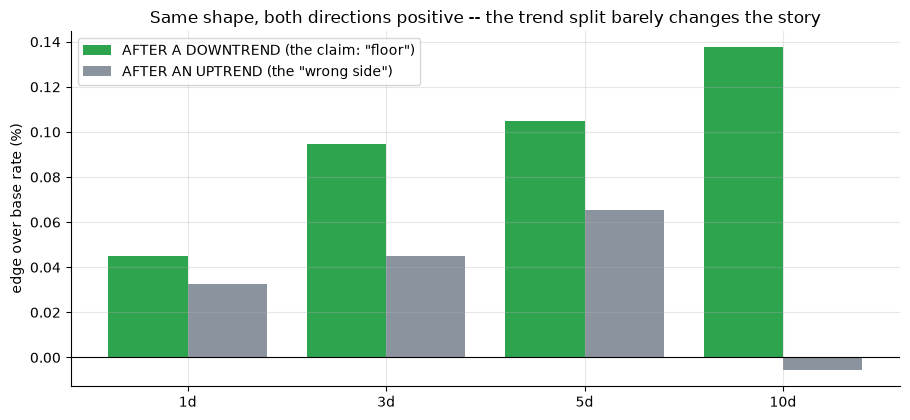

after downtrend: [0.045, 0.095, 0.105, 0.137]  after uptrend: [0.033, 0.045, 0.065, -0.005]


In [3]:
if HAVE_REAL:
    ri = st.run_experiment(PANEL, side='invhammer', placebo=False, n_draws=1, seed=684)
    rs = st.run_experiment(PANEL, side='star', placebo=False, n_draws=1, seed=684)
    ih = [ri[h]['edge_mean']*100 for h in HS]; sr = [rs[h]['edge_mean']*100 for h in HS]
else:
    ih = [R['invh'][h][1] for h in HS]; sr = [R['star'][h][1]/100 for h in HS]
x = np.arange(len(HS))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, ih, .4, color=GREEN, label='AFTER A DOWNTREND (the claim: "floor")')
ax.bar(x+.2, sr, .4, color=GREY, label='AFTER AN UPTREND (the "wrong side")')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in HS])
ax.set_ylabel('edge over base rate (%)')
ax.set_title('Same shape, both directions positive -- the trend split barely changes the story')
ax.legend(); plt.tight_layout(); plt.show()
print('after downtrend:', [round(v,3) for v in ih], ' after uptrend:', [round(v,3) for v in sr])

Both bars lean the same way at almost every horizon. If "buyers overwhelming exhausted sellers after a slide" were the real mechanism, the *wrong-side* version shouldn't look like a smaller copy of the same thing — it should look different, or negative. It doesn't. That's a second strike against the story, on top of the *t*-stat never clearing the bar.

**The give-away: the filter rescue.** Believers say "sure, but you need the *right* setup — a real washout, not just any downtrend." So we tried. Watch what happens to the 3-day edge as we change the filters.

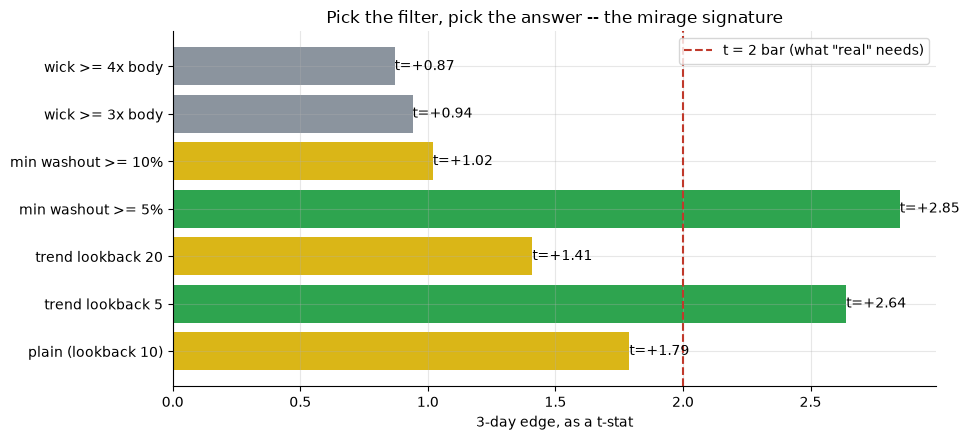

plain (lookback 10)    edge=+0.095%  t=+1.79  n=4895
trend lookback 5       edge=+0.134%  t=+2.64  n=4906
trend lookback 20      edge=+0.077%  t=+1.41  n=4785
min washout >= 5%      edge=+0.413%  t=+2.85  n=1265
min washout >= 10%     edge=+0.527%  t=+1.02  n=257
wick >= 3x body        edge=+0.072%  t=+0.94  n=2486
wick >= 4x body        edge=+0.092%  t=+0.87  n=1408


In [4]:
labels = [f[0] for f in R['filt']]; tvals = [f[2] for f in R['filt']]
fig, ax = plt.subplots(figsize=(9.8, 4.5))
cols = [GREEN if t>=2 else (AMBER if t>=1 else GREY) for t in tvals]
ax.barh(range(len(labels)), tvals, color=cols)
ax.axvline(2, ls='--', c=RED, label='t = 2 bar (what "real" needs)')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i,t in enumerate(tvals): ax.annotate(f't={t:+.2f}',(t,i),va='center',ha='left' if t>=0 else 'right')
ax.set_xlabel('3-day edge, as a t-stat'); ax.set_title('Pick the filter, pick the answer -- the mirage signature')
ax.legend(); plt.tight_layout(); plt.show()
for f in R['filt']: print(f'{f[0]:22s} edge={f[1]:+.3f}%  t={f[2]:+.2f}  n={f[4]}')

A **shorter** trend window or a **deeper washout filter** *can* nudge *t* above 2 — tantalisingly close! — but push the washout filter *further still* (from 5% to 10%) and it **falls back down** to under 1.1 on a thin sample, and demanding a *longer, purer* wick — the "textbook-perfect" inverted hammer — **flattens it to under 1**. When the answer swings with the knob you chose, and doesn't even move consistently as you turn the knob further, you're not finding a signal. You're fishing.

## 5 · The verdict

- **Signal — None.** Best edge **+0.095% at 3 days, *t* = +1.79** — under the bar, and it doesn't survive correcting for the four horizons tested at once. The "wrong-side" version (after an uptrend) looks almost the same, undercutting the trend-conditional story itself. Only 2 of 26 names individually show a real-looking edge — about what chance predicts.
- **Tradability — Mirage.** After normal costs, the edge is **negative or a rounding error at every horizon that matters.**
- **Deeper washout rescues it? — Busted.** The only "edges" come from tuning a filter, and they don't even move consistently as you tune it further — a bigger wick makes it *worse*.

## 6 · Could you actually trade it? — costs finish it off

Even granting the tiny gross blip at its best horizon (3 days), here's what a normal 5-bps round trip does to it.

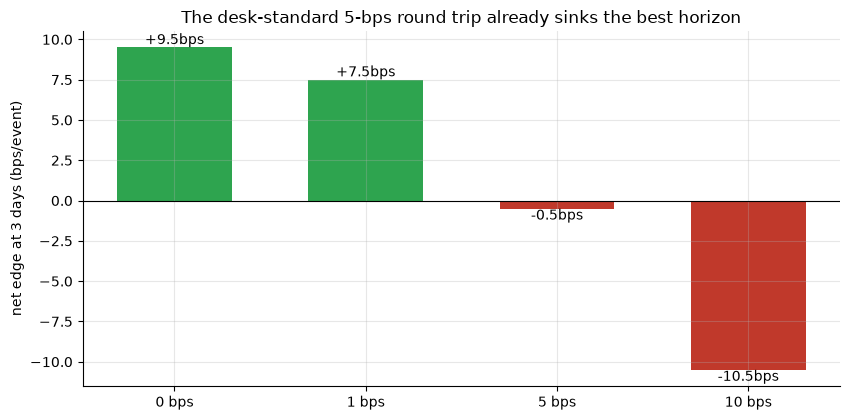

cost sweep (bps one-way -> net bps): [(0.0, 9.5), (1.0, 7.5), (5.0, -0.5), (10.0, -10.5)]


In [5]:
labels = [f'{c:.0f} bps' for c,_ in R['costs']]
vals = [n for _,n in R['costs']]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
cols = [GREEN if v>0 else RED for v in vals]
ax.bar(labels, vals, color=cols, width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}bps',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('net edge at 3 days (bps/event)')
ax.set_title('The desk-standard 5-bps round trip already sinks the best horizon')
plt.tight_layout(); plt.show()
print('cost sweep (bps one-way -> net bps):', R['costs'])

At the desk's standard **5 bps one-way**, the 3-day inverted hammer's net edge is already **negative**. Break-even sits under 2 bps — well inside the real bid-ask spread of any of these names. There was never a robust gross edge worth defending, and ordinary trading costs bury what little there was.

## 7 · Going further 🚪

- **The wick is real, the forecast isn't.** A long upper shadow genuinely tells you buyers fought back *that day*. The lesson is that *intraday* information isn't a *multi-day* forecast — the same trap that sinks the hammer, the hanging man and the shooting star.
- **Try small-caps / intraday.** Candle effects are bigger (and costlier) in illiquid names; re-run on a small-cap basket or on intraday bars and see if a thin edge appears.
- **Combine with a real signal.** An inverted hammer *plus* an earnings surprise or a real reversal factor might do something the candle alone can't. Fork it and show the **net** edge clearing *t* = 2, Bonferroni-corrected, and we'll talk.

*The reproducible core is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*